In [1]:
import PriceRatioExperiment as PRE

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import random

from scipy.signal import find_peaks
from sklearn.mixture import GaussianMixture



import time

In [2]:
N = 100 # Number of agents

T = 1_000 # Length of Simulation

Mmax = 100 # Max possible money per agent
theta = 0.001 # Proportional change of prices in market
epsilon = 0.5 # Proportion of randomizing prices for agent
max_tries = 1000 # Max number of market attempts

# Define Productivity Coefficients (Direct Labor Coefficients)
l1 = 10.0
l2 = 1.0

# Define the desired consumption rate
c1 = 0.1/2.
c2 = 1.0/2.

# The macro-economic condition must be satisfied
# l1*c1 + l2*c2 <= 1.0
print(l1*c1 + l2*c2)



1.0


In [3]:
#np.logspace(-3, np.log10(0.99), 50)

In [4]:
#theta_array = [0.0001, 0.001, 0.01, 0.1, 0.5, 0.9]
theta_array = np.logspace(-3, np.log10(0.99), 20)

iterations = len(theta_array)

# Start grabbing data at this time
start_time = 1

theta_df =  np.zeros((iterations))
epsilon_df = np.zeros((iterations))
Me_avg_df = np.zeros((iterations, 2))
Me_std_df = np.zeros((iterations, 2))
Qe_avg_df = np.zeros((iterations, 2))
Qe_std_df = np.zeros((iterations, 2))
p_avg_df = np.zeros((iterations, 2))
p_std_df = np.zeros((iterations, 2))
p_ratio_avg_df = np.zeros((iterations, 2))
p_ratio_std_df = np.zeros((iterations, 2))
ntries_avg_df = np.zeros((iterations, 2))
logM_peaks_df = np.zeros((iterations, 2))
logM_spread_df = np.zeros((iterations, 2))


for i,theta in enumerate(theta_array):
    
    print(i, iterations, theta)
    # Inititialize Market Simulation
    sim = PRE.PriceRatioExperiment(N, l1, l2, c1, c2, 
                                   Mmax=Mmax, 
                                   theta=theta, 
                                   epsilon=epsilon, 
                                   max_tries=max_tries, 
                                   initial_money='uniform')

    # Run simulation
    start_ = time.time()
    Me_df, Qe_df, ntries_df, p_df, Magent_df = sim.run_experiment(T)
    end_ = time.time()

    # Grab data
    Me_avg = Me_df[start_time:].mean(axis=0)
    Me_std = Me_df[start_time:].std(axis=0)

    Qe_avg = Qe_df[start_time:].mean(axis=0)
    Qe_std = Qe_df[start_time:].std(axis=0)

    p_avg = np.nanmean(p_df[start_time:], axis=0)
    p_std = np.nanstd(p_df[start_time:], axis=0)

    p_ratio_ = p_df[start_time:,1]/p_df[start_time:,0]
    p_ratio_avg = np.nanmean(p_ratio_)
    p_ratio_std = np.nanstd(p_ratio_)

    ntries_avg = np.mean(ntries_df[start_time:])

    # Find peaks of money distribution
    data = np.log10(Magent_df[start_time:].mean(axis=0))

    gmm = GaussianMixture(n_components=2)
    gmm.fit(data.reshape(-1,1))
    logM_peaks = gmm.means_.flatten()
    logM_peaks = logM_peaks[np.argsort(logM_peaks)[::-1]]
    logM_spread = gmm.covariances_.flatten()
    logM_spread = logM_spread[np.argsort(logM_peaks)[::-1]]
    
    # Store data
    theta_df[i] = theta
    epsilon_df[i] = epsilon
    
    Me_avg_df[i] = Me_avg
    Me_std_df[i] = Me_std
    
    Qe_avg_df[i] = Qe_avg
    Qe_std_df[i] = Qe_std
    
    p_avg_df[i] = p_avg
    p_std_df[i] = p_std
    
    p_ratio_avg_df[i] = p_ratio_avg
    p_ratio_std_df[i] = p_ratio_std
    
    ntries_avg_df[i] = ntries_avg
    
    logM_peaks_df[i] = logM_peaks
    logM_spread_df[i] = logM_spread
    

0 20 0.001


C:\Users\Alex\Documents\Research\EconoABM\EconoNet\2024-07-08_Testing_Simple_Continuous_Double_Auction_Market\PriceRatioExperiment.py:109: RuntimeWarning: invalid value encountered in divide
  self.p_df = self.Me_df/self.Qe_df
C:\Users\Alex\anaconda3\envs\pytorchgame3.10\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


1 20 0.001437689199784439


C:\Users\Alex\Documents\Research\EconoABM\EconoNet\2024-07-08_Testing_Simple_Continuous_Double_Auction_Market\PriceRatioExperiment.py:109: RuntimeWarning: invalid value encountered in divide
  self.p_df = self.Me_df/self.Qe_df
C:\Users\Alex\anaconda3\envs\pytorchgame3.10\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


2 20 0.002066950235176821


...

C:\Users\Alex\Documents\Research\EconoABM\EconoNet\2024-07-08_Testing_Simple_Continuous_Double_Auction_Market\PriceRatioExperiment.py:109: RuntimeWarning: invalid value encountered in divide
  self.p_df = self.Me_df/self.Qe_df
C:\Users\Alex\anaconda3\envs\pytorchgame3.10\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


18 20 0.6886050198808176


C:\Users\Alex\Documents\Research\EconoABM\EconoNet\2024-07-08_Testing_Simple_Continuous_Double_Auction_Market\PriceRatioExperiment.py:109: RuntimeWarning: invalid value encountered in divide
  self.p_df = self.Me_df/self.Qe_df
C:\Users\Alex\anaconda3\envs\pytorchgame3.10\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


19 20 0.99


C:\Users\Alex\Documents\Research\EconoABM\EconoNet\2024-07-08_Testing_Simple_Continuous_Double_Auction_Market\PriceRatioExperiment.py:109: RuntimeWarning: invalid value encountered in divide
  self.p_df = self.Me_df/self.Qe_df
C:\Users\Alex\anaconda3\envs\pytorchgame3.10\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Plotting

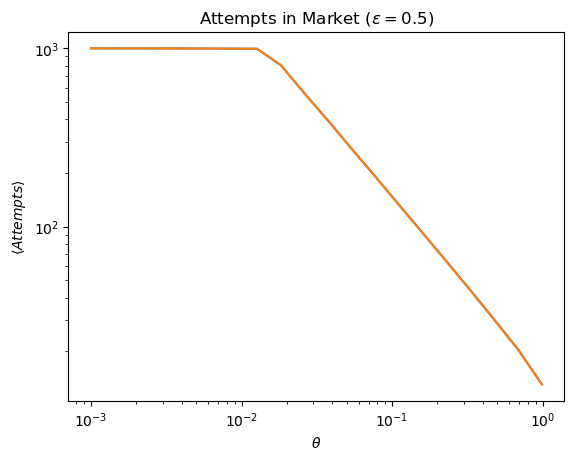

In [5]:
plt.plot(theta_array, ntries_avg_df)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\langle Attempts \rangle$')
plt.title(f'Attempts in Market ($\epsilon={epsilon}$)')
plt.show()

### M

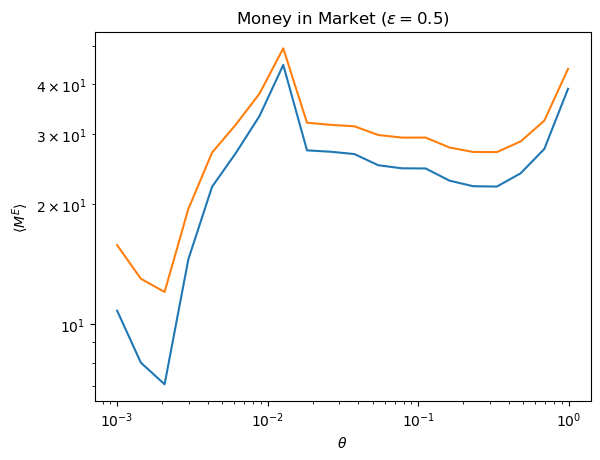

In [6]:
plt.plot(theta_array, Me_avg_df)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\langle M^E \rangle$')
plt.title(f'Money in Market ($\epsilon={epsilon}$)')
plt.show()

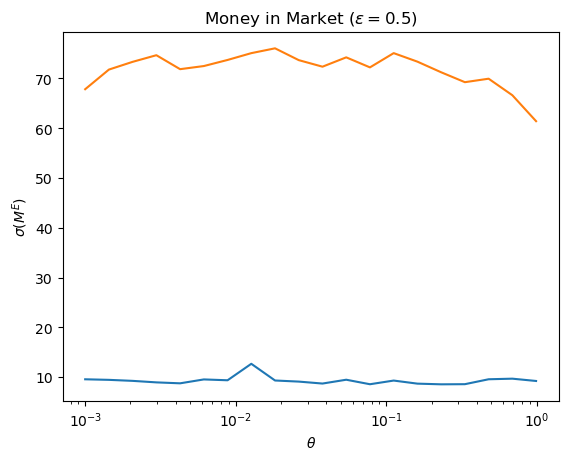

In [7]:
plt.plot(theta_array, Me_std_df)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\sigma(M^E)$')
plt.title(f'Money in Market ($\epsilon={epsilon}$)')
plt.show()

### Q

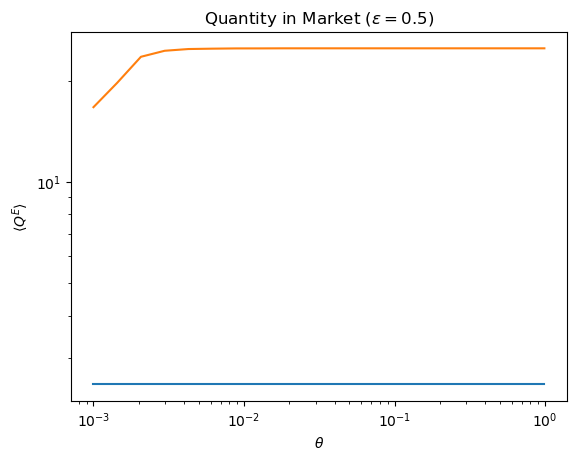

In [8]:
plt.plot(theta_array, Qe_avg_df)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\langle Q^E \rangle$')
plt.title(f'Quantity in Market ($\epsilon={epsilon}$)')
plt.show()

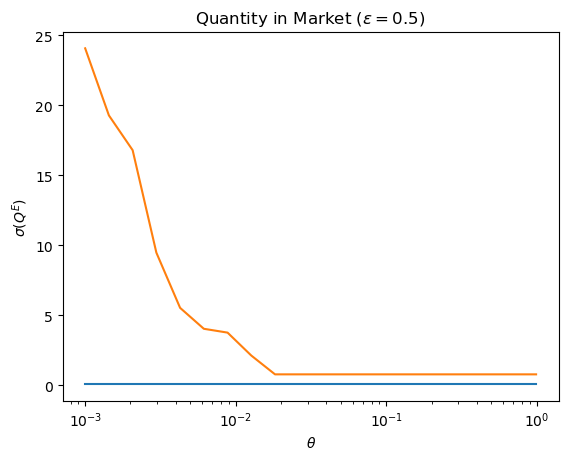

In [9]:
plt.plot(theta_array, Qe_std_df)
plt.xscale('log')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\sigma(Q^E)$')
plt.title(f'Quantity in Market ($\epsilon={epsilon}$)')
plt.show()

### p

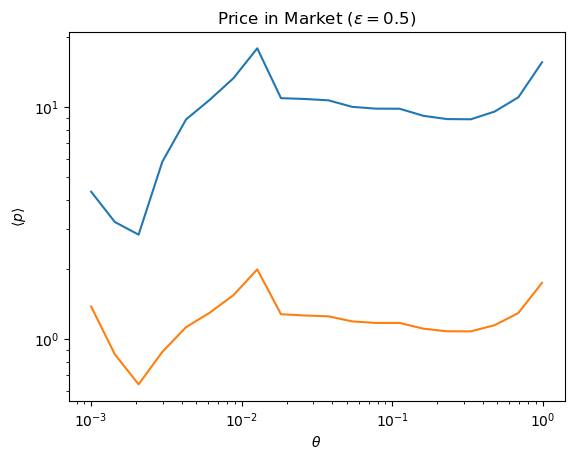

In [10]:
plt.plot(theta_array, p_avg_df)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\langle p \rangle$')
plt.title(f'Price in Market ($\epsilon={epsilon}$)')
plt.show()

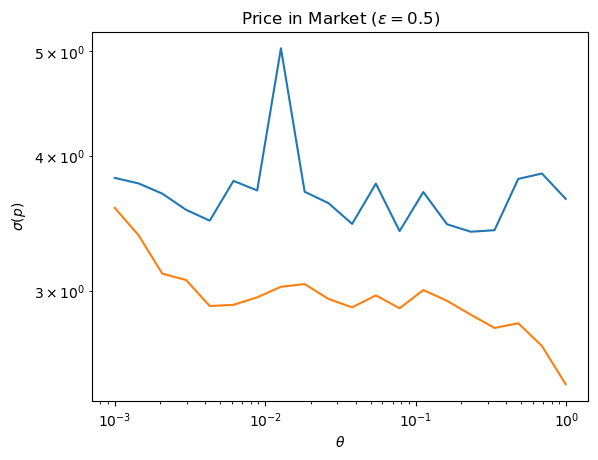

In [11]:
plt.plot(theta_array, p_std_df)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\sigma(p)$')
plt.title(f'Price in Market ($\epsilon={epsilon}$)')
plt.show()

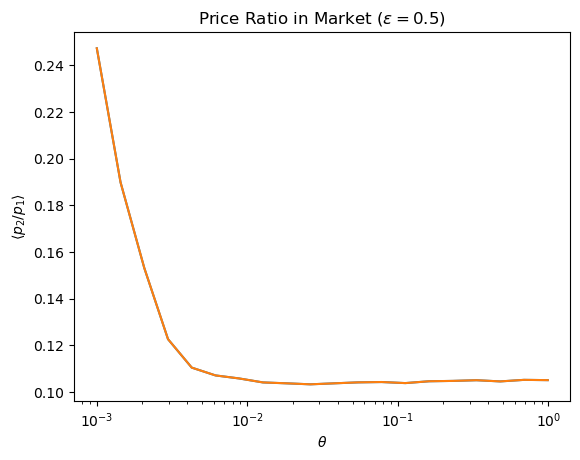

In [12]:
plt.plot(theta_df, p_ratio_avg_df)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\langle p_2/p_1 \rangle $')
plt.title(f'Price Ratio in Market ($\epsilon={epsilon}$)')
plt.show()

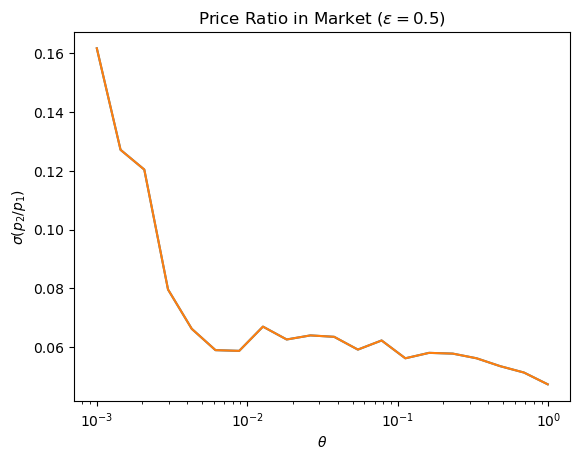

In [13]:
plt.plot(theta_df, p_ratio_std_df)
plt.xscale('log')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\sigma(p_2/p_1)$')
plt.title(f'Price Ratio in Market ($\epsilon={epsilon}$)')
plt.show()

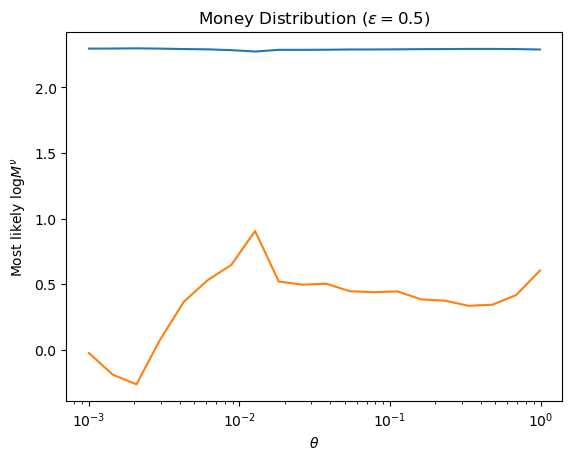

In [14]:
plt.plot(theta_df, logM_peaks_df)
plt.xscale('log')
plt.xlabel(r'$\theta$')
plt.ylabel(r'Most likely log$M^\nu$')
plt.title(f'Money Distribution ($\epsilon={epsilon}$)')
plt.show()


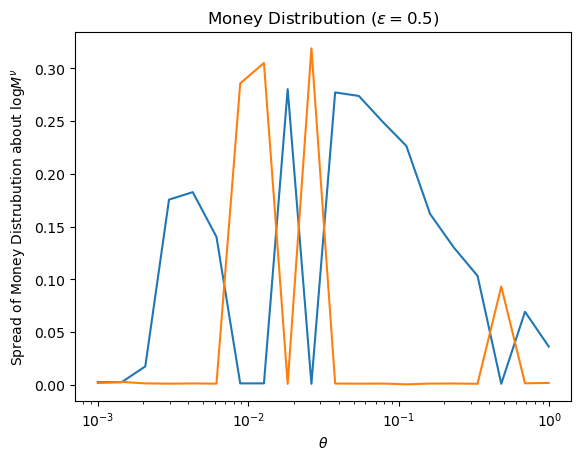

In [15]:
plt.plot(theta_df, logM_spread_df)
plt.xscale('log')
plt.xlabel(r'$\theta$')
plt.ylabel(r'Spread of Money Distrubution about log$M^\nu$')
plt.title(f'Money Distribution ($\epsilon={epsilon}$)')
plt.show()

In [16]:
assert False

AssertionError: 

In [ ]:
start_time = 100

In [ ]:
Me_avg = Me_df[start_time:].mean(axis=0)
Me_std = Me_df[start_time:].std(axis=0)

Qe_avg = Qe_df[start_time:].mean(axis=0)
Qe_std = Qe_df[start_time:].std(axis=0)

p_avg = np.nanmean(p_df[start_time:], axis=0)
p_std = np.nanstd(p_df[start_time:], axis=0)

p_ratio_ = p_df[start_time:,1]/p_df[start_time:,0]
p_ratio_avg = np.nanmean(p_ratio_)
p_ratio_std = np.nanstd(p_ratio_)

ntries_avg = np.mean(ntries_df[start_time:])

In [ ]:
data = np.log10(Magent_df[start_time:].mean(axis=0))

gmm = GaussianMixture(n_components=2)
gmm.fit(data.reshape(-1,1))
logM_peaks = gmm.means_.flatten()
logM_spread = gmm.covariances_.flatten()

In [ ]:
lapse = end_ - start_
print(lapse, lapse/N)

In [ ]:
sim.scda.agent_data.shape

In [ ]:
f, ax = plt.subplots()
ax.plot(ntries_df, lw=0.5)
ax.set_xlabel('$t$')
ax.set_ylabel('Market Attempts')

In [ ]:
plt.rcParams['figure.dpi'] = 300
f, ax = plt.subplots(3,1, figsize=(8,8))
for i in range(2):
    ax[0].plot(Me_df[:,i], label=f'$M^E_{i+1}$', lw=0.5)
    ax[1].plot(Qe_df[:,i], label=f'%Q^E_{i+1}$', lw=0.5)
ax[2].plot(p_df, label=f'$p_{i+1}$', lw=0.5)
    
    
ax[0].legend()
ax[0].set_yscale('log')
ax[2].set_yscale('log')
ax[2].set_xlabel('$t$')
ax[0].set_ylabel('Money Used in Market')
ax[1].set_ylabel('Quantity Traded in Market')
ax[2].set_ylabel('Price')

In [ ]:
plt.plot(p_df[:,1]/p_df[:,0], label=f'$p_2/p_1$', lw=0.5)
plt.axhline(l2/l1, lw=0.5, c='k')
plt.yscale('log')


In [ ]:
f, ax = plt.subplots()

for t in np.arange(0, T, 100):
    ax.hist(Magent_df[t], histtype='step', bins=50, label=f'$t={t}$')
ax.legend()

In [ ]:
Magent_df[5:].mean(axis=0)

In [ ]:
plt.hist(Magent_df[100:].mean(axis=0), histtype='step', bins=50)
plt.show()

In [ ]:
from scipy.signal import find_peaks
from sklearn.mixture import GaussianMixture

In [ ]:
start_time = 1
data = np.log10(Magent_df[start_time:].mean(axis=0))
plt.hist(data, bins=30)

In [ ]:
# Finding peaks in the histogram
nbins = 25
hist, bin_edges = np.histogram(data, bins=nbins)
peaks, _ = find_peaks(hist)

peaks, _

In [ ]:
gmm = GaussianMixture(n_components=2)
gmm.fit(data.reshape(-1,1))
gmm.means_.flatten()

In [ ]:
assert False

In [ ]:
N = 100
num = 11

prod_values = np.logspace(-1, 1, num)
labor_coeffs = 1.0/prod_values

In [ ]:
T = 500

n = len(labor_coeffs)
n = n*n

l_ratio_df = []
p_ratio_df = []
p_ratio_std_df = []
c1_df = []

for l1 in labor_coeffs:
    
    print(l1)
    
    for l2 in labor_coeffs:
        
        try:
    
            c1 = np.random.uniform(0, 1.0/l1)
            c2 = 1.0/l2*(1.0 - l1*c1)

            pre = PRE.PriceRatioExperiment(N, l1, l2, c1, c2)
            print(l1, l2)
            print(c1, c2)
            print(pre.N1, pre.N2)
            print(l1*c1 + l2*c2)
            print()

            Me_df, Qe_df, ntries_df, p_df = pre.run_experiment(T)

            p_ratio     = np.nanmean(p_df[:,0]/p_df[:,1])
            p_ratio_std = np.nanstd(p_df[:,0]/p_df[:,1])

            
        except:
            
            print('Fail for')
            print(l1, l2)
            print()
            
            p_ratio = np.nan
            p_ratio_std = np.nan
        
        l_ratio_df.append(l1/l2)
        p_ratio_df.append(p_ratio)
        p_ratio_std_df.append(p_ratio_std)
        c1_df.append(c1)

        
        
        

In [ ]:
plt.scatter(l_ratio_df, p_ratio_df, s = 0.5, c='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Productivity Ratios ($l_1/l_2$)')
plt.ylabel('Price Ratios ($p_1/p_2$)')

x = np.logspace(-3,3,10)
plt.plot(x,x, c='k', lw=0.1)
plt.xlim(5e-3, 2e2)
plt.ylim(5e-3, 2e2)

In [ ]:
plt.scatter(p_ratio_df, p_ratio_std_df, c='k', s=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Price Ratios ($p_1/p_2$)')
plt.ylabel('Price Ratio Standard Deviations')

In [ ]:
plt.scatter(p_ratio_df, c1_df, c='k', s=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Price Ratios ($p_1/p_2$)')
plt.ylabel(r'$\bar{c}_1$')